**BO1: Aide les entreprises à anticiper les métiers à recruter et adapter leurs plans RH et formation**
Classifier des métiers selon trajectoire 2024→2030(croissance / stable / déclin).

knn - tree, XGBoost, Logistic Regression

In [105]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, 
                           precision_score, recall_score, f1_score, precision_recall_fscore_support,
                           balanced_accuracy_score, make_scorer)
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
import xgboost as xgb
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')


In [106]:
df = pd.read_csv(r"C:\Users\meria\Downloads\mlProject\prepared_data.csv")
print(df.shape)
if 'Growth_Category' not in df.columns:
    print("ERREUR: Colonne 'Growth_Category' introuvable!")
    print(f"   Colonnes disponibles: {df.columns.tolist()}")
else:
    print(f"Target trouvée: Growth_Category")

(10000, 29)
Target trouvée: Growth_Category


In [107]:
# Show the relationship
df_check = df[['Job_Growth_Rate_%', 'Growth_Category']].copy()
print("\nSample data:")
print(df_check.head(20))
print("\nGrowth_Category by Job_Growth_Rate_% ranges:")
for gc in ['decline', 'stable', 'high_growth']:
    mask = df['Growth_Category'] == gc
    growth_rates = df.loc[mask, 'Job_Growth_Rate_%']
    print(f"\n{gc}:")
    print(f"  Min: {growth_rates.min():.2f}")
    print(f"  Max: {growth_rates.max():.2f}")
    print(f"  Mean: {growth_rates.mean():.2f}")
    print(f"  Median: {growth_rates.median():.2f}")


Sample data:
    Job_Growth_Rate_% Growth_Category
0           -0.221243     high_growth
1            2.162397     high_growth
2           -0.183681     high_growth
3           -0.276264         decline
4           -0.128388     high_growth
5           -0.383077         decline
6           -0.108286     high_growth
7           -0.037372     high_growth
8           -0.156120     high_growth
9           -0.409677         decline
10          -0.321495         decline
11          -0.235966     high_growth
12           0.048621     high_growth
13          -0.345567         decline
14           0.284301     high_growth
15          -0.393359         decline
16           0.469314     high_growth
17           0.072187     high_growth
18          -0.371477         decline
19          -0.307241         decline

Growth_Category by Job_Growth_Rate_% ranges:

decline:
  Min: -0.43
  Max: -0.27
  Mean: -0.35
  Median: -0.35

stable:
  Min: -0.27
  Max: -0.24
  Mean: -0.26
  Median: -0.26

high_growt

**Préparation des features**

In [108]:
target = "Growth_Category"

LEAKAGE_FEATURES = [
    'Job_Growth_Rate_%',       
    'Growth_Category',          
]

X = df.select_dtypes(include=[np.number]).copy()
X = X.drop(columns=[col for col in LEAKAGE_FEATURES if col in X.columns])
y = df[target].copy()

print(f"\nFeatures used: {X.shape[1]}")
print(f"Feature list: {X.columns.tolist()}")
print(f"\nTarget distribution:")
print(y.value_counts())


Features used: 26
Feature list: ['Median_Salary_USD', 'Experience_Required_Years', 'Remote_Work_Ratio_%', 'Automation_Risk_%', 'Gender_Diversity_%', 'Job_Value_Index', 'Vulnerability_Index', 'Required_Education_num', 'AI_Impact_Level_num', 'Job_Status_num', 'Industry_education', 'Industry_entertainment', 'Industry_finance', 'Industry_healthcare', 'Industry_it', 'Industry_manufacturing', 'Industry_retail', 'Industry_transportation', 'Location_australia', 'Location_brazil', 'Location_canada', 'Location_china', 'Location_germany', 'Location_india', 'Location_uk', 'Location_usa']

Target distribution:
Growth_Category
decline        4552
high_growth    4513
stable          935
Name: count, dtype: int64


In [109]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

**Split des données**

In [110]:
# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

smote = SMOTE(sampling_strategy='auto', random_state=42, k_neighbors=3)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print(f"Train set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"Before SMOTE: {np.bincount(y_train)}")
print(f"After SMOTE: {np.bincount(y_train_smote)}")

Train set: (8000, 26)
Test set: (2000, 26)
Before SMOTE: [3642 3610  748]
After SMOTE: [3642 3642 3642]


# **KNN**

In [111]:
# KNN Baseline
knn_baseline = KNeighborsClassifier(n_neighbors=5)
knn_baseline.fit(X_train_scaled, y_train)
y_pred_knn_baseline = knn_baseline.predict(X_test_scaled)
acc_knn_baseline = accuracy_score(y_test, y_pred_knn_baseline)


print(f" KNN Baseline - Accuracy: {acc_knn_baseline:.3f}")
print("\nRapport de classification KNN basique :")
print(classification_report(y_test, y_pred_knn_baseline, target_names=le.classes_))


 KNN Baseline - Accuracy: 0.447

Rapport de classification KNN basique :
              precision    recall  f1-score   support

     decline       0.45      0.55      0.50       910
 high_growth       0.45      0.43      0.44       903
      stable       0.07      0.01      0.01       187

    accuracy                           0.45      2000
   macro avg       0.32      0.33      0.32      2000
weighted avg       0.41      0.45      0.43      2000



**Optimisation KNN avec GridSearchCV**

In [112]:
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}
# Utiliser balanced_accuracy comme métrique
knn_grid = GridSearchCV(
    KNeighborsClassifier(), 
    param_grid_knn, 
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='balanced_accuracy',
    n_jobs=-1
)
knn_grid.fit(X_train_smote, y_train_smote)

best_knn = knn_grid.best_estimator_
y_pred_knn_opt = best_knn.predict(X_test_scaled)
acc_knn_opt = accuracy_score(y_test, y_pred_knn_opt)
bal_acc_knn = balanced_accuracy_score(y_test, y_pred_knn_opt)

**evaluation**

In [113]:
print(f" KNN OPTIMISÉ - Performances:")
print(f"   • Accuracy: {acc_knn_opt:.4f}")
print(f"   • Balanced Accuracy: {bal_acc_knn:.4f}")
print(f"   • Meilleurs paramètres: {knn_grid.best_params_}")

print("\nRapport de classification KNN optimisé :")
print(classification_report(y_test, y_pred_knn_opt, target_names=le.classes_))

 KNN OPTIMISÉ - Performances:
   • Accuracy: 0.3785
   • Balanced Accuracy: 0.3237
   • Meilleurs paramètres: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}

Rapport de classification KNN optimisé :
              precision    recall  f1-score   support

     decline       0.45      0.39      0.42       910
 high_growth       0.46      0.41      0.43       903
      stable       0.08      0.17      0.11       187

    accuracy                           0.38      2000
   macro avg       0.33      0.32      0.32      2000
weighted avg       0.42      0.38      0.40      2000



**visualisation**

Matrice de confusion

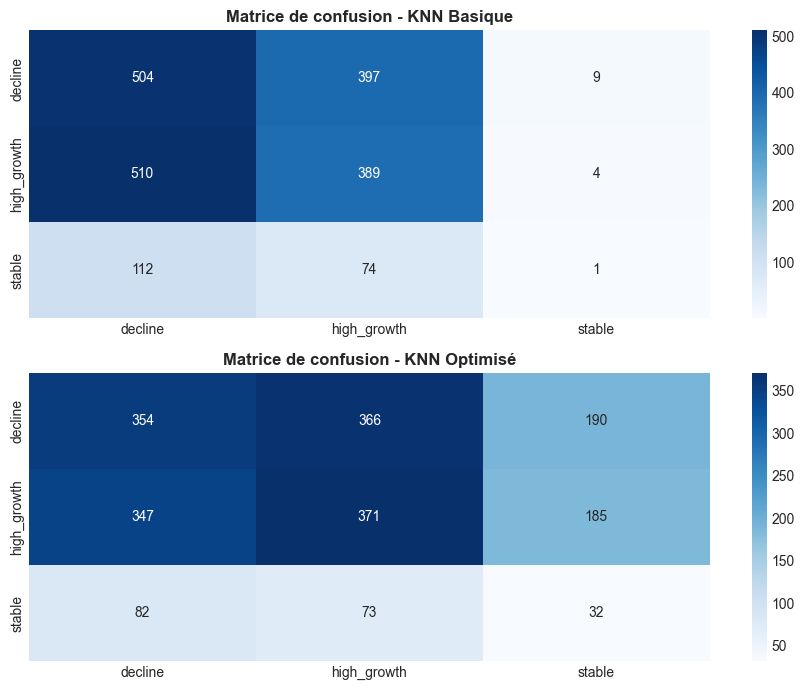

In [114]:
plt.figure(figsize=(9, 7))
plt.subplot(2, 1, 1)
cm_basic = confusion_matrix(y_test, y_pred_knn_baseline)
sns.heatmap(cm_basic, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Matrice de confusion - KNN Basique", fontweight='bold')
plt.grid(True, alpha=0.3)

plt.subplot(2, 1, 2)

cm_opt = confusion_matrix(y_test, y_pred_knn_opt)
sns.heatmap(cm_opt, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Matrice de confusion - KNN Optimisé", fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

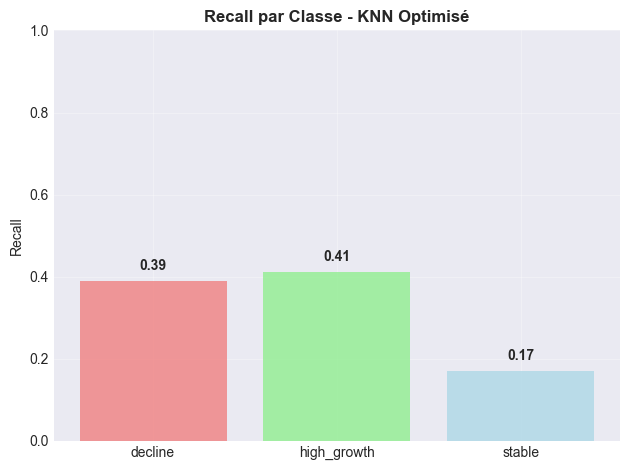

In [115]:
recall_knn = recall_score(y_test, y_pred_knn_opt, average=None)
plt.bar(le.classes_, recall_knn, color=['lightcoral', 'lightgreen', 'lightblue'], alpha=0.8)
plt.title('Recall par Classe - KNN Optimisé', fontweight='bold')
plt.ylabel('Recall')
plt.ylim(0, 1)
for i, v in enumerate(recall_knn):
    plt.text(i, v + 0.02, f'{v:.2f}', ha='center', va='bottom', fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

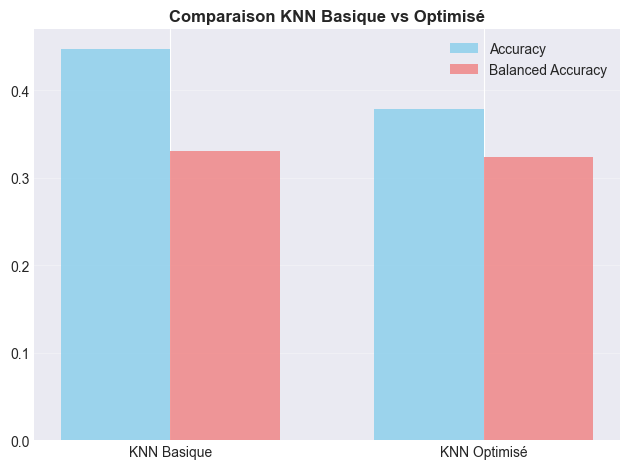

In [116]:
models_comparison_knn = pd.DataFrame({
    'Modèle': ['KNN Basique', 'KNN Optimisé'],
    'Accuracy': [acc_knn_baseline, acc_knn_opt],
    'Balanced Accuracy': [balanced_accuracy_score(y_test, y_pred_knn_baseline), bal_acc_knn]
})
x_pos = np.arange(len(models_comparison_knn))
width = 0.35
plt.bar(x_pos - width/2, models_comparison_knn['Accuracy'], width, 
        label='Accuracy', alpha=0.8, color='skyblue')
plt.bar(x_pos + width/2, models_comparison_knn['Balanced Accuracy'], width, 
        label='Balanced Accuracy', alpha=0.8, color='lightcoral')
plt.title('Comparaison KNN Basique vs Optimisé', fontweight='bold')
plt.xticks(x_pos, models_comparison_knn['Modèle'])
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

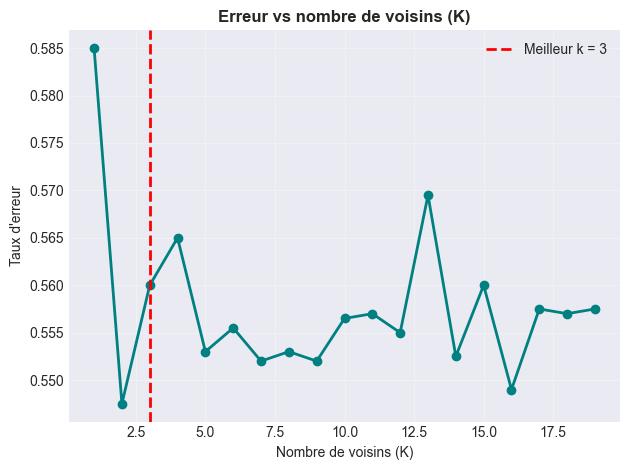

In [117]:
errors = []
neighbors_range = range(1, 20)
for k in neighbors_range:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    pred_k = model.predict(X_test_scaled)
    errors.append(1 - accuracy_score(y_test, pred_k))
plt.plot(neighbors_range, errors, marker='o', linestyle='-', color='teal', linewidth=2, markersize=6)
plt.axvline(x=knn_grid.best_params_['n_neighbors'], color='red', linestyle='--', 
            label=f'Meilleur k = {knn_grid.best_params_["n_neighbors"]}', linewidth=2)
plt.title("Erreur vs nombre de voisins (K)", fontweight='bold')
plt.xlabel("Nombre de voisins (K)")
plt.ylabel("Taux d'erreur")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# **Modèle Arbre de Décision** 


In [118]:
# Arbre Baseline
tree_baseline = DecisionTreeClassifier(random_state=42)
tree_baseline.fit(X_train, y_train)
y_pred_tree_baseline = tree_baseline.predict(X_test)
acc_tree_baseline = accuracy_score(y_test, y_pred_tree_baseline)

In [119]:

print(f"Arbre Baseline (défaut) - Accuracy: {acc_tree_baseline:.3f}")
print(f"   • Profondeur: {tree_baseline.get_depth()}")
print(f"   • Feuilles: {tree_baseline.get_n_leaves()}")

Arbre Baseline (défaut) - Accuracy: 0.417
   • Profondeur: 44
   • Feuilles: 2410


**Optimisation Arbre**

In [120]:
tree_baseline = DecisionTreeClassifier(random_state=42)
tree_baseline.fit(X_train, y_train)
y_pred_tree_baseline = tree_baseline.predict(X_test)
acc_tree_baseline = accuracy_score(y_test, y_pred_tree_baseline)

print(f"Arbre Baseline (défaut) - Accuracy: {acc_tree_baseline:.3f}")
print(f"  Profondeur: {tree_baseline.get_depth()}")
print(f"  Feuilles: {tree_baseline.get_n_leaves()}")

Arbre Baseline (défaut) - Accuracy: 0.417
  Profondeur: 44
  Feuilles: 2410


**Optimisation Arbre avec GridSearchCV**

In [121]:
param_grid_tree = {
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [10, 20, 50],
    'min_samples_leaf': [5, 10, 20],
    'criterion': ['gini', 'entropy'],
    'class_weight': ['balanced', {0:1, 1:1, 2:3}],
    'max_features': ['sqrt', 'log2', None]
}

grid_search_tree = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_tree,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='balanced_accuracy',
    n_jobs=-1,
    verbose=1
)
grid_search_tree.fit(X_train_smote, y_train_smote)

best_tree = grid_search_tree.best_estimator_
y_pred_tree = best_tree.predict(X_test)
acc_tree = accuracy_score(y_test, y_pred_tree)
bal_acc_tree = balanced_accuracy_score(y_test, y_pred_tree)

print(f"ARBRE OPTIMISÉ - Performances:")
print(f"  • Accuracy: {acc_tree:.4f}")
print(f"  • Balanced Accuracy: {bal_acc_tree:.4f}")
print(f"  • Meilleurs paramètres: {grid_search_tree.best_params_}")

print("\n Rapport de classification Arbre optimisé :")
print(classification_report(y_test, y_pred_tree, target_names=le.classes_))

Fitting 5 folds for each of 540 candidates, totalling 2700 fits
ARBRE OPTIMISÉ - Performances:
  • Accuracy: 0.1350
  • Balanced Accuracy: 0.3270
  • Meilleurs paramètres: {'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 20, 'max_features': None, 'min_samples_leaf': 5, 'min_samples_split': 20}

 Rapport de classification Arbre optimisé :
              precision    recall  f1-score   support

     decline       0.45      0.07      0.12       910
 high_growth       0.42      0.05      0.09       903
      stable       0.09      0.86      0.17       187

    accuracy                           0.14      2000
   macro avg       0.32      0.33      0.13      2000
weighted avg       0.40      0.14      0.11      2000



# Validation Croisée Arbre


In [122]:
cv_scores_tree = cross_val_score(best_tree, X_train, y_train, cv=5, scoring='accuracy')
print(f"\nVALIDATION CROISÉE ARBRE:")
print(f"  • Scores CV: {[f'{s:.4f}' for s in cv_scores_tree]}")
print(f"  • Moyenne:   {cv_scores_tree.mean():.4f} (± {cv_scores_tree.std():.4f})")

# Importance des features
importances_tree = pd.Series(best_tree.feature_importances_, index=X.columns)
importances_tree = importances_tree.sort_values(ascending=False)
top_features_tree = importances_tree[importances_tree > 0].head(15)

print(f"\nTOP {len(top_features_tree)} FEATURES IMPORTANTES - ARBRE:")
for i, (feature, importance) in enumerate(top_features_tree.items(), 1):
   
    print(f"   {i:2d}. {feature:35} {importance:7.4f} ")


VALIDATION CROISÉE ARBRE:
  • Scores CV: ['0.3450', '0.2775', '0.3594', '0.3350', '0.3319']
  • Moyenne:   0.3297 (± 0.0278)

TOP 15 FEATURES IMPORTANTES - ARBRE:
    1. Required_Education_num               0.4493 
    2. Job_Value_Index                      0.0701 
    3. Gender_Diversity_%                   0.0700 
    4. Median_Salary_USD                    0.0665 
    5. Automation_Risk_%                    0.0629 
    6. AI_Impact_Level_num                  0.0596 
    7. Remote_Work_Ratio_%                  0.0529 
    8. Vulnerability_Index                  0.0415 
    9. Experience_Required_Years            0.0374 
   10. Industry_retail                      0.0123 
   11. Job_Status_num                       0.0107 
   12. Location_australia                   0.0077 
   13. Industry_healthcare                  0.0068 
   14. Industry_it                          0.0064 
   15. Location_india                       0.0063 


**Visualisations Arbre**


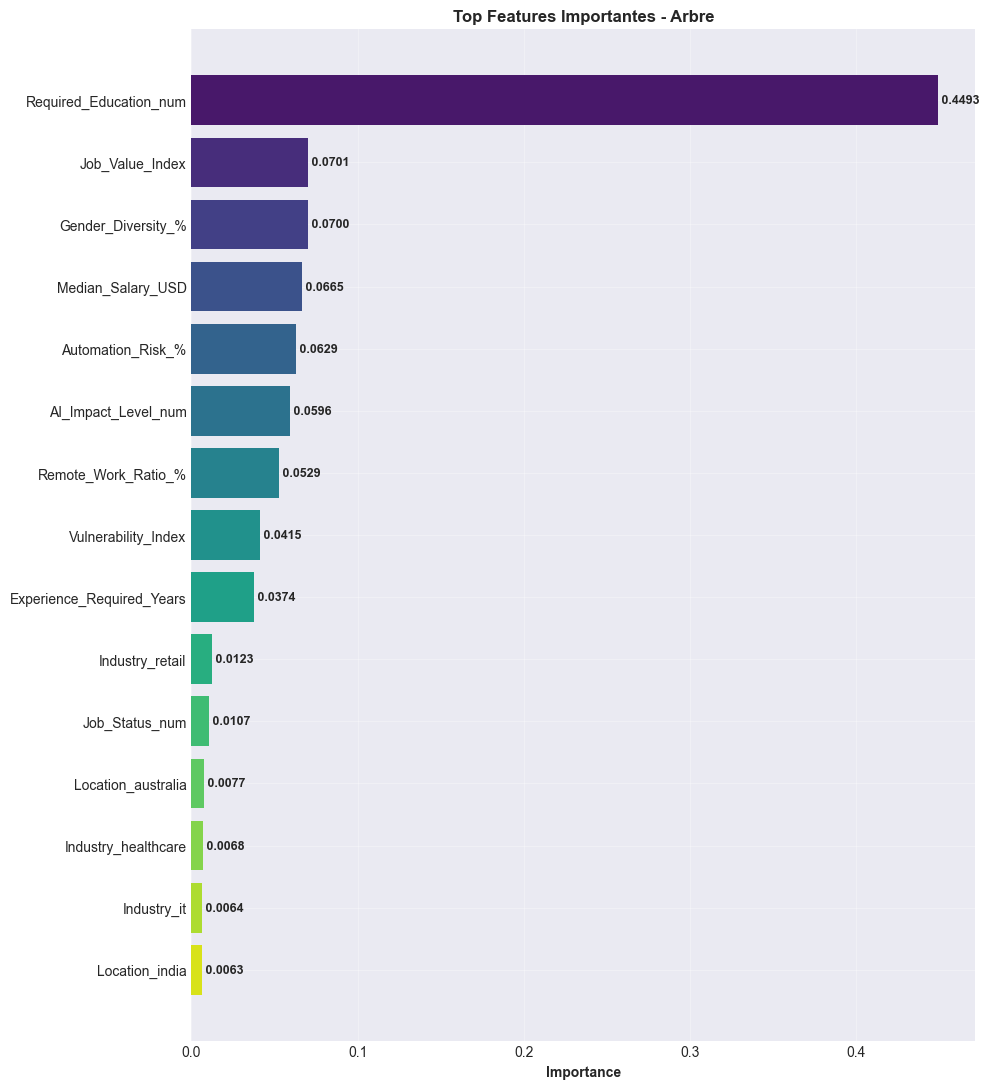

In [123]:
plt.figure(figsize=(10, 11))
colors = sns.color_palette("viridis", len(top_features_tree))
bars = plt.barh(range(len(top_features_tree)), top_features_tree.values, color=colors)
plt.yticks(range(len(top_features_tree)), top_features_tree.index)
plt.xlabel('Importance', fontweight='bold')
plt.title('Top Features Importantes - Arbre', fontweight='bold')
plt.gca().invert_yaxis()
for i, (bar, val) in enumerate(zip(bars, top_features_tree.values)):
    plt.text(val, i, f' {val:.4f}', va='center', fontsize=9, fontweight='bold')

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

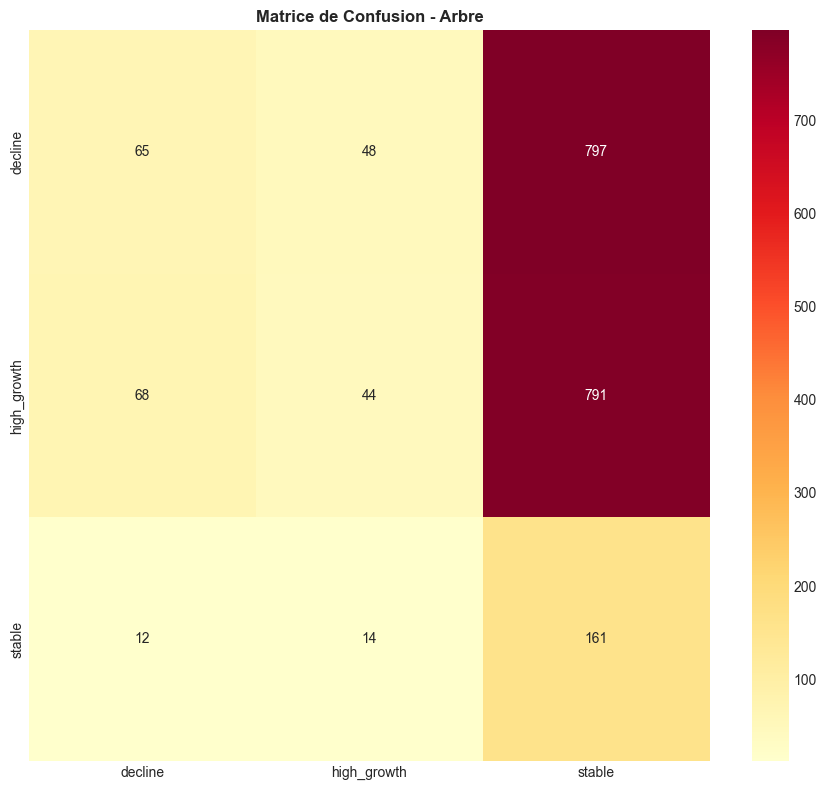

In [124]:
plt.figure(figsize=(9, 8))
cm_tree = confusion_matrix(y_test, y_pred_tree)
sns.heatmap(cm_tree, annot=True, fmt='d', cmap='YlOrRd',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Matrice de Confusion - Arbre', fontweight='bold')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

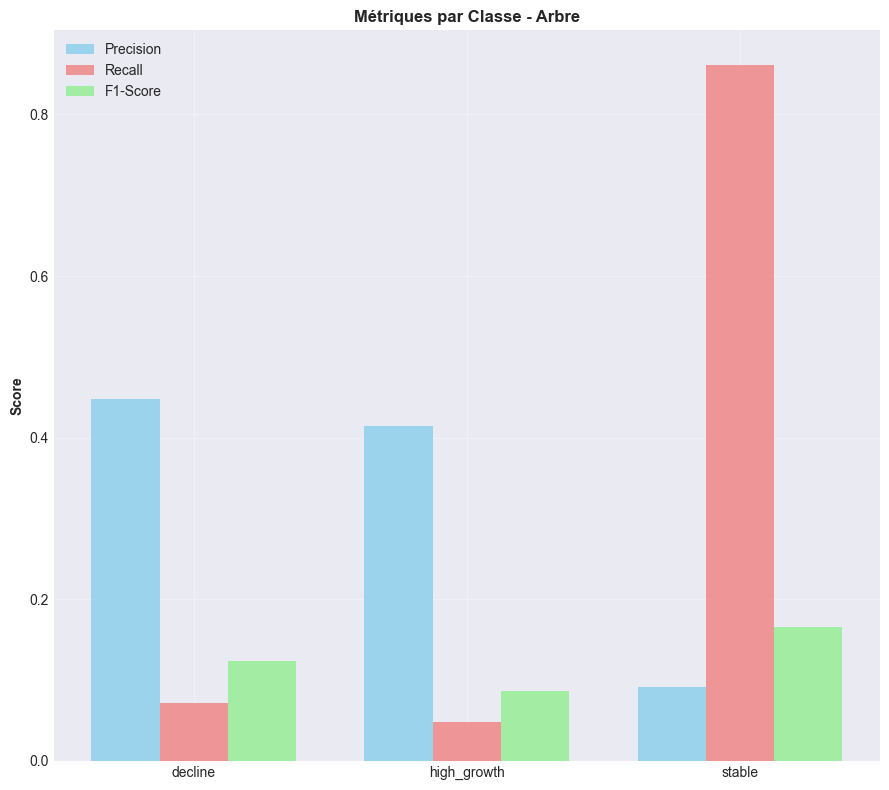

In [125]:
plt.figure(figsize=(9, 8))
precision_tree, recall_tree, f1_tree, _ = precision_recall_fscore_support(y_test, y_pred_tree, average=None)
x_pos = np.arange(len(le.classes_))
width = 0.25
plt.bar(x_pos - width, precision_tree, width, label='Precision', alpha=0.8, color='skyblue')
plt.bar(x_pos, recall_tree, width, label='Recall', alpha=0.8, color='lightcoral')
plt.bar(x_pos + width, f1_tree, width, label='F1-Score', alpha=0.8, color='lightgreen')
plt.ylabel('Score', fontweight='bold')
plt.title('Métriques par Classe - Arbre', fontweight='bold')
plt.xticks(x_pos, le.classes_)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

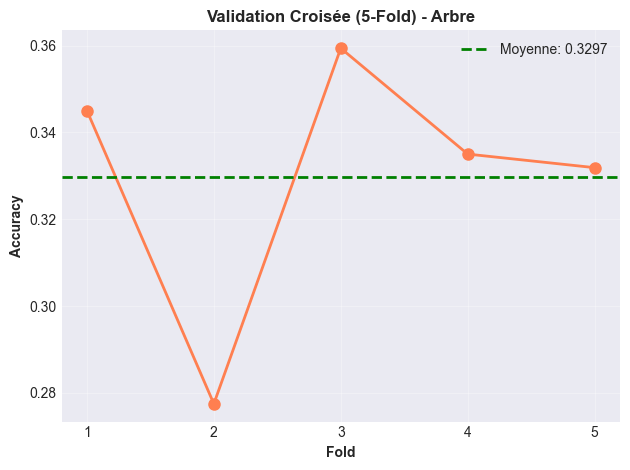

In [126]:
plt.plot(range(1, 6), cv_scores_tree, 'o-', linewidth=2, markersize=8, color='coral')
plt.axhline(cv_scores_tree.mean(), color='green', linestyle='--', 
           label=f'Moyenne: {cv_scores_tree.mean():.4f}', linewidth=2)
plt.xlabel('Fold', fontweight='bold')
plt.ylabel('Accuracy', fontweight='bold')
plt.title('Validation Croisée (5-Fold) - Arbre', fontweight='bold')
plt.xticks(range(1, 6))
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

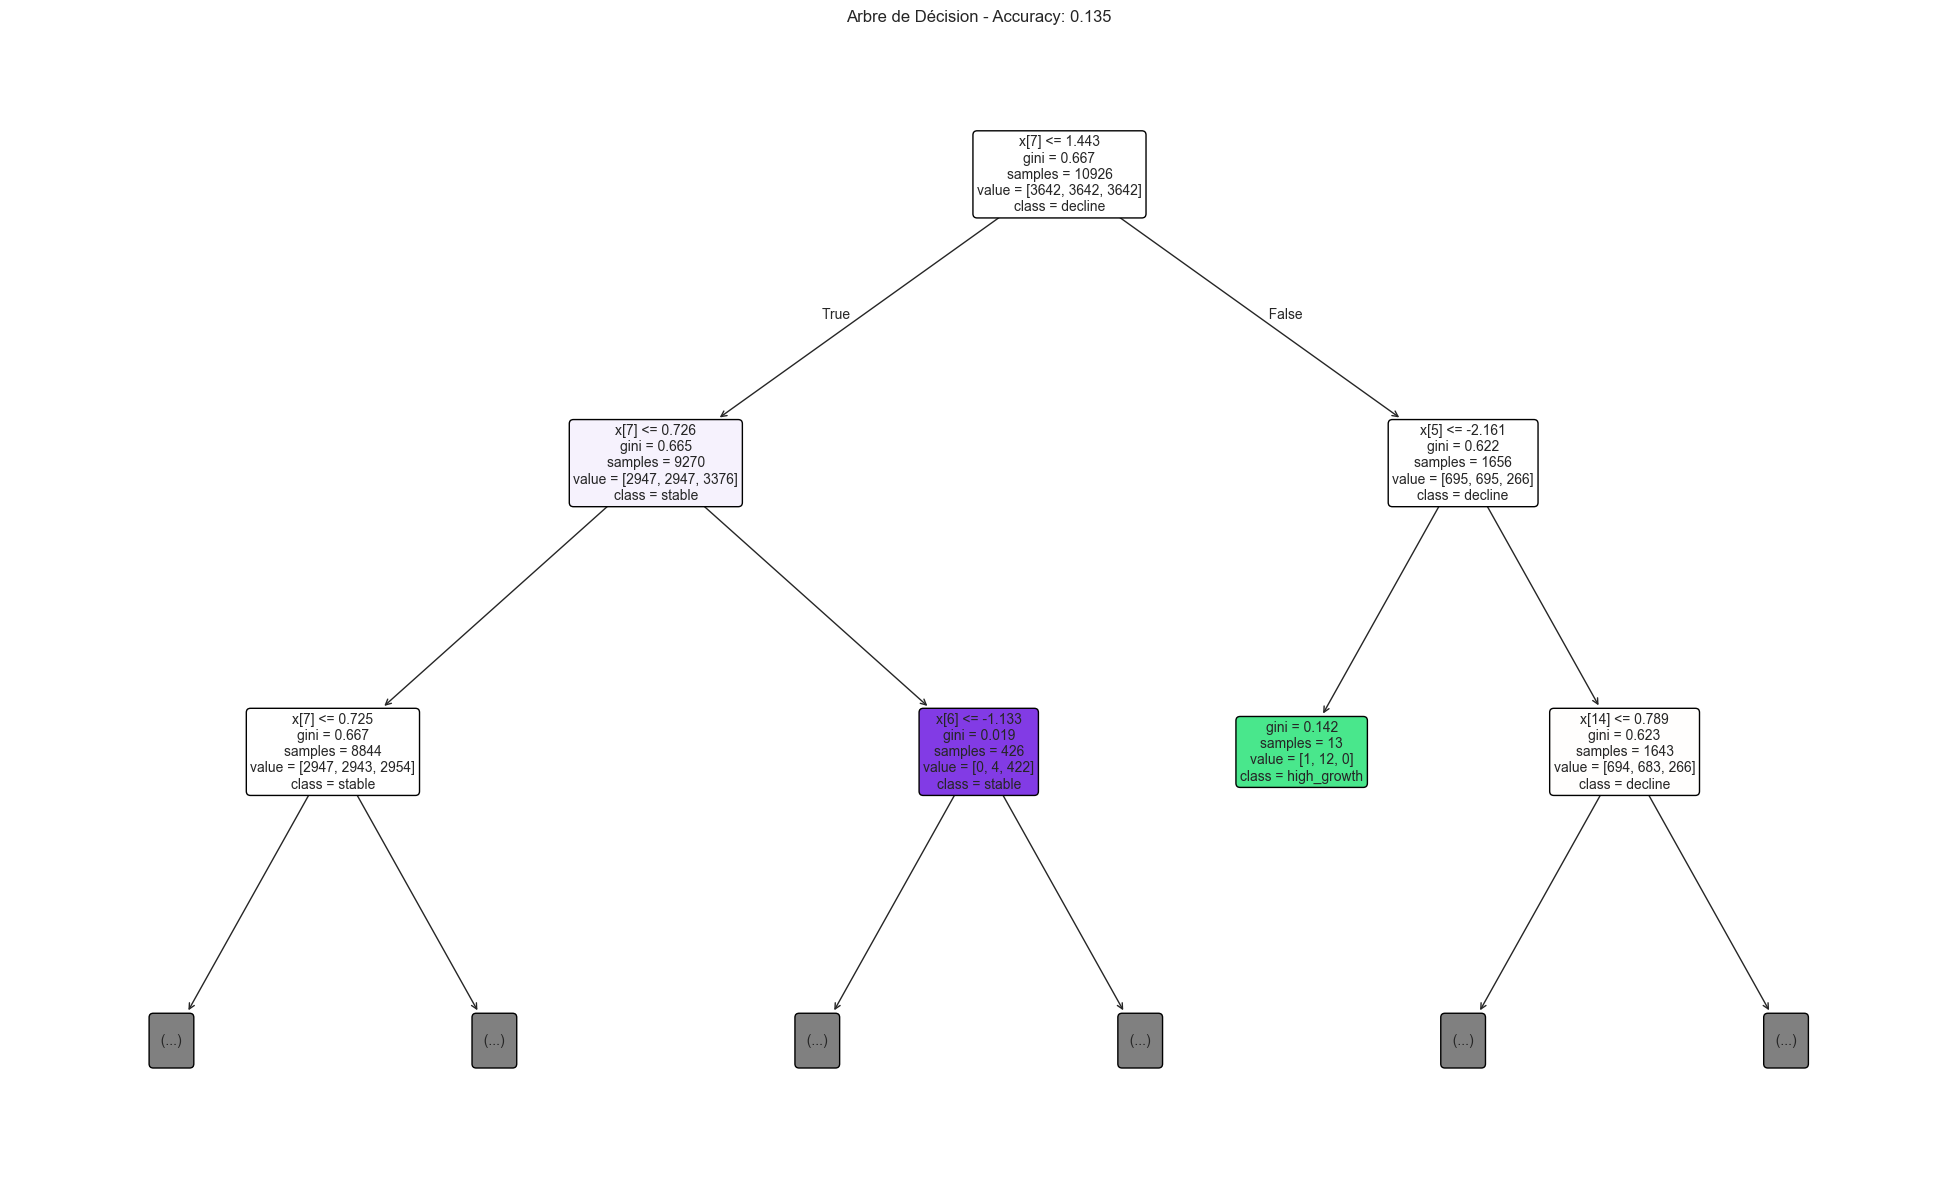

In [127]:
fig = plt.figure(figsize=(25, 15))
plot_tree(best_tree,
         class_names=le.classes_,
         filled=True,
         rounded=True,
         fontsize=10,
         max_depth=2)  # Show only 2 levels
plt.title(f'Arbre de Décision - Accuracy: {acc_tree:.3f}')
plt.show()

# **Régression Linéaire**


In [128]:
# Regression Baseline
lr_baseline = LogisticRegression(random_state=42, max_iter=1000)
lr_baseline.fit(X_train_scaled, y_train)
y_pred_lr_baseline = lr_baseline.predict(X_test_scaled)
acc_lr_baseline = accuracy_score(y_test, y_pred_lr_baseline)

print(f"Regression Baseline - Accuracy: {acc_lr_baseline:.3f}")

Regression Baseline - Accuracy: 0.481


In [129]:
# Optimisation Regression
param_grid_lr = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2', 'elasticnet'],
    'solver': ['liblinear', 'saga'],
    'class_weight': ['balanced', {0:1, 1:1, 2:3}]
}

lr_grid = GridSearchCV(
    LogisticRegression(random_state=42, max_iter=2000),
    param_grid_lr,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='balanced_accuracy',
    n_jobs=-1,
    verbose=1
)
print("Recherche des meilleurs paramètres pour la regression...")
lr_grid.fit(X_train_smote, y_train_smote)

Recherche des meilleurs paramètres pour la regression...
Fitting 5 folds for each of 72 candidates, totalling 360 fits


,estimator,LogisticRegre...ndom_state=42)
,param_grid,"{'C': [0.001, 0.01, ...], 'class_weight': ['balanced', {0: 1, 1: 1, 2: 3}], 'penalty': ['l1', 'l2', ...], 'solver': ['liblinear', 'saga']}"
,scoring,'balanced_accuracy'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l1'


In [130]:
best_lr = lr_grid.best_estimator_
y_pred_lr = best_lr.predict(X_test_scaled)
acc_lr = accuracy_score(y_test, y_pred_lr)
bal_acc_lr = balanced_accuracy_score(y_test, y_pred_lr)

print(f" RÉGRESSION OPTIMISÉE - Performances:")
print(f"  • Accuracy: {acc_lr:.4f}")
print(f"  • Balanced Accuracy: {bal_acc_lr:.4f}")
print(f"  • Meilleurs paramètres: {lr_grid.best_params_}")

print("\n Rapport de classification Regression optimisée :")
print(classification_report(y_test, y_pred_lr, target_names=le.classes_))

 RÉGRESSION OPTIMISÉE - Performances:
  • Accuracy: 0.2635
  • Balanced Accuracy: 0.3245
  • Meilleurs paramètres: {'C': 0.01, 'class_weight': 'balanced', 'penalty': 'l1', 'solver': 'saga'}

 Rapport de classification Regression optimisée :
              precision    recall  f1-score   support

     decline       0.56      0.04      0.07       910
 high_growth       0.45      0.44      0.45       903
      stable       0.09      0.49      0.15       187

    accuracy                           0.26      2000
   macro avg       0.37      0.32      0.22      2000
weighted avg       0.47      0.26      0.25      2000



# **XGboost**

In [131]:
df = pd.read_csv(r'C:\Users\meria\Downloads\mlProject\dataset_reduit.csv')
print(f"Shape: {df.shape}")
print(f"Colonnes: {list(df.columns)}")
print("\nAperçu des 5 premières lignes :")
df.head()

Shape: (10000, 9)
Colonnes: ['PC1', 'PC2', 'PC3', 'PC4', 'Job_Title', 'Growth_Category', 'AI_Impact_Level', 'Industry', 'Location']

Aperçu des 5 premières lignes :


,PC1,PC2,PC3,PC4,Job_Title,Growth_Category,AI_Impact_Level,Industry,Location
0,-0.581580,0.803116,-1.338874,0.048520,research scientist (life sciences),high_growth,moderate,finance,canada
1,-0.347918,-0.739927,0.530097,0.758618,tefl teacher,high_growth,moderate,entertainment,usa
2,0.521165,-1.445746,-0.153673,1.125908,"editor, magazine features",high_growth,low,entertainment,india
3,1.254101,-0.001815,-1.181334,0.527434,"journalist, magazine",decline,low,entertainment,china
4,-0.565290,-1.988752,0.866313,-0.270646,"engineer, land",high_growth,low,transportation,australia


In [132]:
# --- VÉRIFICATION DES COLONNES REQUISES ---
required_columns = [
    'Job_Title', 'Growth_Category', 'AI_Impact_Level'
]

missing_cols = [col for col in required_columns if col not in df.columns]
if missing_cols:
    print(f"\nERREUR : Colonnes manquantes : {missing_cols}")
    print("Assure-toi que les noms de colonnes correspondent exactement.")
else:
    print("Toutes les colonnes nécessaires sont présentes !")

Toutes les colonnes nécessaires sont présentes !


In [133]:
# --- PREPARATION DES DONNEES ---
# Encode the target variable 'Growth_Category'
le_growth_category = LabelEncoder()
df['Growth_Category_encoded'] = le_growth_category.fit_transform(df['Growth_Category'])

print(f"Mapping Growth Category: {dict(zip(le_growth_category.classes_, le_growth_category.transform(le_growth_category.classes_)))}")

# Features are the PCA components (PC1 to PC18)
features_bo1 = [col for col in df.columns if col.startswith('PC')]

X = df[features_bo1]
y = df['Growth_Category_encoded']

print(f"Features used for classification: {features_bo1}")
print(f"Target variable: Growth_Category")
print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


Mapping Growth Category: {'decline': 0, 'high_growth': 1, 'stable': 2}
Features used for classification: ['PC1', 'PC2', 'PC3', 'PC4']
Target variable: Growth_Category
Shape of X: (10000, 4)
Shape of y: (10000,)


In [134]:
print("ENTRAINEMENT DU MODÈLE XGBOOST")

# Initialize and train the XGBoost Classifier
model = xgb.XGBClassifier(objective='multi:softmax', num_class=len(le_growth_category.classes_), eval_metric='mlogloss', use_label_encoder=False, random_state=42)
model.fit(X_train, y_train)


ENTRAINEMENT DU MODÈLE XGBOOST


,objective,'multi:softmax'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'mlogloss'


In [135]:
# --- ÉVALUATION DU MODÈLE ---
print("ÉVALUATION DU MODÈLE")

y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le_growth_category.classes_))

# Feature Importance
print("IMPORTANCE DES FEATURES")
# Get feature importance from the trained model
feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(feature_importances.head(10).to_string(index=False))

ÉVALUATION DU MODÈLE
Accuracy: 0.4855

Classification Report:
              precision    recall  f1-score   support

     decline       0.48      0.56      0.52       910
 high_growth       0.50      0.51      0.50       903
      stable       0.00      0.00      0.00       187

    accuracy                           0.49      2000
   macro avg       0.33      0.36      0.34      2000
weighted avg       0.44      0.49      0.46      2000

IMPORTANCE DES FEATURES
Feature  Importance
    PC2    0.261235
    PC1    0.261100
    PC4    0.241501
    PC3    0.236165


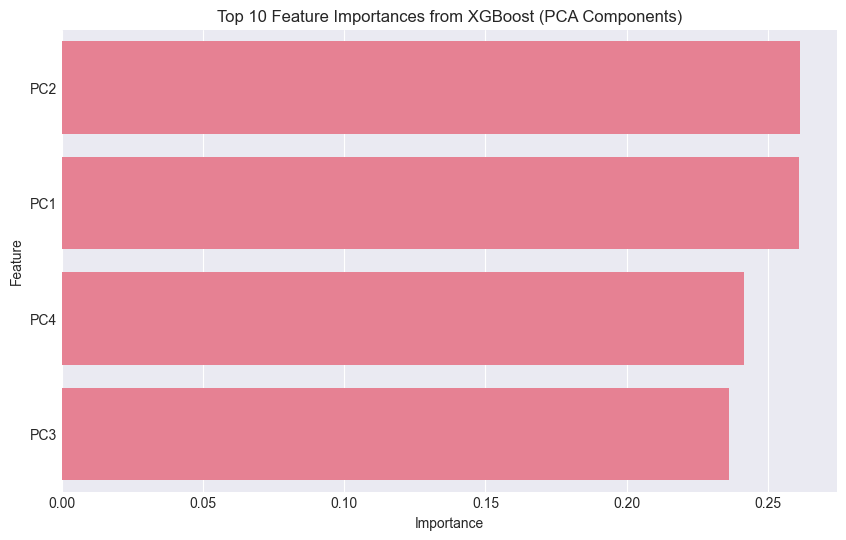

In [136]:
# Visualize Feature Importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importances.head(10))
plt.title('Top 10 Feature Importances from XGBoost (PCA Components)')
plt.show()

In [137]:
import xgboost as xgb
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score
import numpy as np

# Re-initialize the base XGBoost model
# Using the same parameters as the initial model trained in J-xlOhWt9Hwn
initial_model_bo1 = xgb.XGBClassifier(objective='multi:softmax', num_class=len(le_growth_category.classes_), eval_metric='mlogloss', use_label_encoder=False, random_state=42)

# Define K-Fold Cross-Validation
num_folds = 5 # You can change the number of folds
kf = KFold(n_splits=num_folds, shuffle=True, random_state=42)

cv_scores = []

print(f"Performing {num_folds}-Fold Cross-Validation...")

for fold, (train_index, val_index) in enumerate(kf.split(X, y)):
    X_train_fold, X_val_fold = X.iloc[train_index], X.iloc[val_index]
    y_train_fold, y_val_fold = y.iloc[train_index], y.iloc[val_index]

    # Train the model on the training fold
    initial_model_bo1.fit(X_train_fold, y_train_fold)

    # Make predictions on the validation fold
    y_pred_fold = initial_model_bo1.predict(X_val_fold)

    # Calculate accuracy for this fold
    fold_accuracy = accuracy_score(y_val_fold, y_pred_fold)
    cv_scores.append(fold_accuracy)
    print(f"Fold {fold+1} Accuracy: {fold_accuracy:.4f}")

print(f"\nMean CV Accuracy: {np.mean(cv_scores):.4f}")
print(f"Std Dev CV Accuracy: {np.std(cv_scores):.4f}")

Performing 5-Fold Cross-Validation...
Fold 1 Accuracy: 0.4865
Fold 2 Accuracy: 0.4820
Fold 3 Accuracy: 0.5035
Fold 4 Accuracy: 0.4800
Fold 5 Accuracy: 0.4900

Mean CV Accuracy: 0.4884
Std Dev CV Accuracy: 0.0083


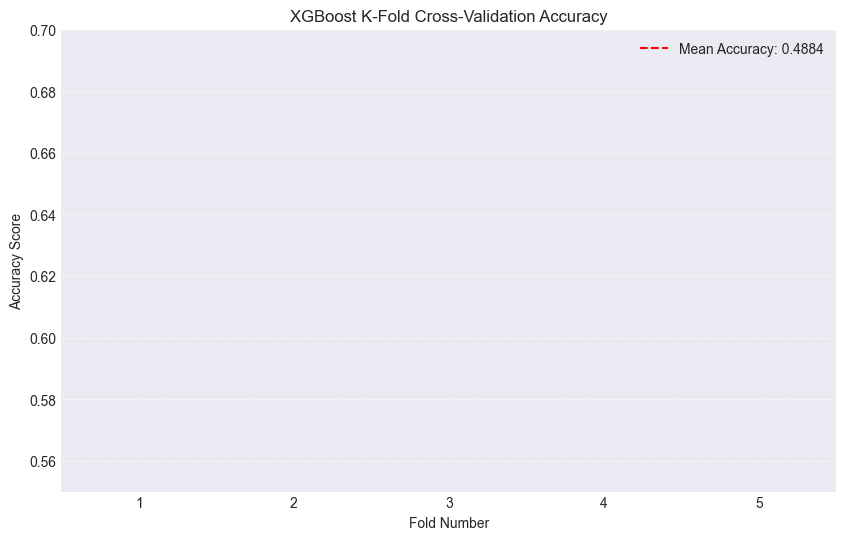

In [138]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np # Ensure numpy is imported for np.mean

# Create a DataFrame for plotting cross-validation scores
cv_results_df = pd.DataFrame({
    'Fold': range(1, num_folds + 1),
    'Accuracy': cv_scores
})
plt.figure(figsize=(10, 6))
sns.barplot(x='Fold', y='Accuracy', data=cv_results_df, palette='viridis', hue='Fold', legend=False)
plt.axhline(y=np.mean(cv_scores), color='r', linestyle='--', label=f'Mean Accuracy: {np.mean(cv_scores):.4f}')
plt.title('XGBoost K-Fold Cross-Validation Accuracy')
plt.xlabel('Fold Number')
plt.ylabel('Accuracy Score')
plt.ylim(0.55, 0.70) # Adjust y-axis for better visualization of scores
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

**Implement Grid Search**


In [139]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for XGBoost
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 1.0],
    'colsample_bytree': [0.7, 1.0]
}

# Initialize the XGBoost Classifier
# num_class should be determined by the unique values in y_train
# It's good practice to ensure the number of classes is correctly identified
num_classes = len(np.unique(y_train))
model_for_grid_search = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=num_classes,
    eval_metric='mlogloss',
    use_label_encoder=False,
    random_state=42
)

# Instantiate GridSearchCV
grid_search = GridSearchCV(
    estimator=model_for_grid_search,
    param_grid=param_grid,
    cv=3, # Using 3-fold cross-validation as an example
    scoring='accuracy',
    verbose=2,
    n_jobs=-1 # Use all available CPU cores
)

print("Starting Grid Search...")
# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

print("\nGrid Search completed!")

# Print the best parameters and best score
print("Best parameters found: ", grid_search.best_params_)
print("Best cross-validation accuracy: {:.4f}".format(grid_search.best_score_))


Starting Grid Search...
Fitting 3 folds for each of 192 candidates, totalling 576 fits


KeyboardInterrupt: 

**Implement Random Search**


In [ ]:
## Implement Random Search
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

# Define the parameter distribution for XGBoost
param_distributions = {
    'n_estimators': randint(50, 200), # Number of boosting rounds
    'max_depth': randint(3, 10),      # Maximum tree depth
    'learning_rate': uniform(0.01, 0.3), # Step size shrinkage to prevent overfitting
    'subsample': uniform(0.6, 0.4),   # Subsample ratio of the training instance
    'colsample_bytree': uniform(0.6, 0.4) # Subsample ratio of columns when constructing each tree
}

# Initialize the XGBoost Classifier
# num_class should be determined by the unique values in y_train
num_classes = len(np.unique(y_train))
model_for_random_search = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=num_classes,
    eval_metric='mlogloss',
    random_state=42
)

# Instantiate RandomizedSearchCV
# n_iter controls the number of parameter settings that are sampled
random_search = RandomizedSearchCV(
    estimator=model_for_random_search,
    param_distributions=param_distributions,
    n_iter=50, # Sample 50 different parameter combinations
    cv=3,      # Using 3-fold cross-validation
    scoring='accuracy',
    verbose=2,
    random_state=42,
    n_jobs=-1  # Use all available CPU cores
)

print("Starting Random Search...")
# Fit RandomizedSearchCV to the training data
random_search.fit(X_train, y_train)

print("\nRandom Search completed!")

# Print the best parameters and best score
print("Best parameters found: ", random_search.best_params_)
print("Best cross-validation accuracy: {:.4f}".format(random_search.best_score_))

Starting Random Search...
Fitting 3 folds for each of 50 candidates, totalling 150 fits

Random Search completed!
Best parameters found:  {'colsample_bytree': 0.7644148053272926, 'learning_rate': 0.019915219870164515, 'max_depth': 3, 'n_estimators': 178, 'subsample': 0.695824756266789}
Best cross-validation accuracy: 0.5136


**Compare Search Results**




In [ ]:
# Retrieve best parameters and score from Grid Search
best_params_grid = grid_search.best_params_
best_score_grid = grid_search.best_score_

# Retrieve best parameters and score from Random Search
best_params_random = random_search.best_params_
best_score_random = random_search.best_score_

print("COMPARISON OF HYPERPARAMETER SEARCH RESULTS")

print("\n--- Grid Search Results ---")
print(f"Best Parameters: {best_params_grid}")
print(f"Best Cross-Validation Accuracy: {best_score_grid:.4f}")

print("\n--- Random Search Results ---")
print(f"Best Parameters: {best_params_random}")
print(f"Best Cross-Validation Accuracy: {best_score_random:.4f}")

print("CONCLUSION")

if best_score_grid > best_score_random:
    print(f"Grid Search yielded a better model configuration with an accuracy of {best_score_grid:.4f}.")
    print(f"Optimal Parameters (Grid Search): {best_params_grid}")
elif best_score_random > best_score_grid:
    print(f"Random Search yielded a better model configuration with an accuracy of {best_score_random:.4f}.")
    print(f"Optimal Parameters (Random Search): {best_params_random}")
else:
    print(f"Both Grid Search and Random Search yielded the same best accuracy of {best_score_grid:.4f}.")
    print(f"Optimal Parameters (Grid Search): {best_params_grid}")
    print(f"Optimal Parameters (Random Search): {best_params_random}")

COMPARISON OF HYPERPARAMETER SEARCH RESULTS

--- Grid Search Results ---
Best Parameters: {'colsample_bytree': 0.7, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.7}
Best Cross-Validation Accuracy: 0.5149

--- Random Search Results ---
Best Parameters: {'colsample_bytree': 0.7644148053272926, 'learning_rate': 0.019915219870164515, 'max_depth': 3, 'n_estimators': 178, 'subsample': 0.695824756266789}
Best Cross-Validation Accuracy: 0.5136
CONCLUSION
Grid Search yielded a better model configuration with an accuracy of 0.5149.
Optimal Parameters (Grid Search): {'colsample_bytree': 0.7, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.7}


**retrain Model with Best Parameters**

In [ ]:
print("RETRAINING XGBOOST MODEL WITH BEST PARAMETERS")
# Identify the best parameters from Random Search
best_params = random_search.best_params_

# Initialize a new XGBClassifier model using these best parameters
num_classes = len(np.unique(y_train))
final_model = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=num_classes,
    eval_metric='mlogloss',
    random_state=42,
    **best_params
)
# Train this new model using the entire training dataset
final_model.fit(X_train, y_train)

print("Final XGBoost model retrained successfully with optimal parameters!")

RETRAINING XGBOOST MODEL WITH BEST PARAMETERS
Final XGBoost model retrained successfully with optimal parameters!


**EVALUATING FINAL MODEL PERFORMANCE**

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

print("EVALUATING FINAL MODEL PERFORMANCE ON TEST SET")

y_pred_final = final_model.predict(X_test)

final_accuracy = accuracy_score(y_test, y_pred_final)
print(f"Final Model Accuracy on Test Set: {final_accuracy:.4f}")

print("\nClassification Report for Final Model:")
print(classification_report(y_test, y_pred_final, target_names=le_growth_category.classes_))

EVALUATING FINAL MODEL PERFORMANCE ON TEST SET
Final Model Accuracy on Test Set: 0.5175

Classification Report for Final Model:
              precision    recall  f1-score   support

     decline       0.50      0.70      0.58       910
 high_growth       0.55      0.44      0.49       903
      stable       0.00      0.00      0.00       187

    accuracy                           0.52      2000
   macro avg       0.35      0.38      0.36      2000
weighted avg       0.48      0.52      0.49      2000

